# Week-1 Foundations — RAG Readiness

Retrieval Augmented Generation (RAG) is an architecture that combines
document retrieval with LLM generation.

Why not Fine-tuning:
• expensive
• static knowledge
• retraining required

Why Traditional Chatbots Fail:
• hallucination
• no external knowledge grounding
• cannot scale with policy data

RAG Architecture:
User Query → Retriever → Relevant Chunks → LLM → Grounded Answer

## Dataset Strategy

Datasets are sourced programmatically using the Hugging Face datasets library.
Controlled subsets are loaded to simulate large-scale policy document ingestion.

Both general text datasets and domain-aligned datasets (e.g., EUR-Lex legal corpus)
are used to test robustness of the ingestion pipeline.

Each dataset record is converted into document-style text files
to support retrieval-based architectures.

## Environment and Tooling Awareness

The broader RAG system design anticipates integration with:

- LangChain for retrieval orchestration
- FAISS for vector indexing
- FastAPI for inference API deployment
- Uvicorn server for model hosting
- dotenv for configuration management

Week 1 focuses only on data engineering preparation.

## Week 1 Data Engineering Goal

The engineering goal is to prepare a clean, traceable, and chunked
document corpus suitable for scalable retrieval.

Key considerations include:
- metadata completeness
- chunk size consistency
- duplicate and empty content validation
- dataset distribution analysis
- repository-ready output structure

In [4]:
from datasets import load_dataset

policy_ds = load_dataset("lex_glue", "eurlex", split="train[:1%]")

print("EURLEX rows:", len(policy_ds))
policy_ds[0]

eurlex/train-00000-of-00001.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

eurlex/test-00000-of-00001.parquet:   0%|          | 0.00/24.3M [00:00<?, ?B/s]

eurlex/validation-00000-of-00001.parquet:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/55000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

EURLEX rows: 550


{'text': 'COUNCIL DECISION\nof 7 June 2005\nabrogating Decision 2005/136/EC on the existence of an excessive deficit in the Netherlands\n(2005/729/EC)\nTHE COUNCIL OF THE EUROPEAN UNION,\nHaving regard to the Treaty establishing the European Community, and in particular Article 104(12) thereof,\nHaving regard to the recommendation from the Commission,\nWhereas:\n(1)\nBy Decision 2005/136/EC (1) following a recommendation from the Commission in accordance with Article 104(6) of the Treaty, the Council decided that an excessive deficit existed in the Netherlands.\n(2)\nIn accordance with Article 104(7) of the Treaty, the Council made a Recommendation on 2 June 2004 addressed to the Netherlands with a view to bringing the excessive deficit situation to an end. This Recommendation, in conjunction with Article 3(4) of Council Regulation (EC) No 1467/97 of 7 July 1997 on speeding up and clarifying the implementation of the excessive deficit procedure (2), established a deadline of 2005 at th

In [6]:
!pip install -q datasets pandas tqdm tiktoken pyarrow

import os
import re
import json
import time
import logging
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset
import tiktoken

# =========================
# 1) REPO STRUCTURE
# =========================
BASE = "hr-compliance-rag"

folders = [
    f"{BASE}/data/raw",
    f"{BASE}/data/processed",
    f"{BASE}/ingestion",
    f"{BASE}/notebooks",
    f"{BASE}/api",
    f"{BASE}/vectorstore",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Repo structure created.")

# =========================
# 2) LOGGING
# =========================
log_file = f"{BASE}/ingestion/ingestion.log"

logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

print(f"Logging to: {log_file}")

# =========================
# 3) TOKENIZER
# =========================
enc = tiktoken.get_encoding("cl100k_base")

def token_len(text: str) -> int:
    return len(enc.encode(str(text)))

# =========================
# 4) CLEANING
# =========================
def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# =========================
# 5) METADATA
# =========================
def enrich_metadata(source_name: str, idx: int, file_name: str) -> dict:
    return {
        "department": "Human Resources",
        "document_type": "Policy/Legal",
        "category": "Compliance",
        "region": "Global",
        "year": 2020 + (idx % 5),
        "source": source_name,
        "file_name": file_name
    }

# =========================
# 6)TEXT EXTRACTION
# =========================
def row_to_text(row):
    if "text" in row and row["text"]:
        text_val = row["text"]

        if isinstance(text_val, list):
            return "\n".join([str(x) for x in text_val if x])

        return str(text_val).strip()

    if "title" in row and "description" in row:
        return f"{row.get('title', '')}\n{row.get('description', '')}".strip()

    if "content" in row:
        return str(row.get("content", "")).strip()

    return ""

# =========================
# 7) DATASET LOADER
# =========================
def load_hf_dataset(dataset_name: str, subset: int = 100, split_candidates=None):
    if split_candidates is None:
        split_candidates = ["train", "validation", "test"]

    for split_name in split_candidates:
        try:
            ds = load_dataset(dataset_name, split=split_name)
            if len(ds) == 0:
                continue
            take_n = min(subset, len(ds))
            logging.info(f"Loaded {dataset_name} [{split_name}] with {take_n} rows")
            return ds.select(range(take_n)), split_name
        except Exception as e:
            logging.warning(f"{dataset_name} split {split_name} failed: {e}")

    logging.error(f"All splits failed for dataset: {dataset_name}")
    return None, None

# =========================
# 8) STABLE DATASETS
# =========================

# These are chosen to avoid old script-based failures.

loaded_datasets = {}

dataset_configs = {
    "ag_news": "ag_news",
    "dbpedia_14": "dbpedia_14",
    "yelp_review_full": "yelp_review_full",
    "emotion": "emotion"
}

documents = []

print("Loading datasets...")

for source_key, dataset_name in dataset_configs.items():
    ds, used_split = load_hf_dataset(dataset_name, subset=120)

    if ds is None:
        print(f"Failed: {dataset_name}")
        continue

    loaded_datasets[source_key] = ds
    print(f"Loaded: {dataset_name} ({used_split}) -> {len(ds)} rows")

    for i, row in enumerate(ds):
        text = row_to_text(row)

        if not text:
            logging.warning(f"Empty extracted text for {source_key}_{i}")
            continue

        file_name = f"{source_key}_{i}.txt"
        raw_path = f"{BASE}/data/raw/{file_name}"

        try:
            with open(raw_path, "w", encoding="utf-8") as f:
                f.write(text)

            meta = enrich_metadata(source_key, i, file_name)
            meta["text"] = text
            documents.append(meta)

        except Exception as e:
            logging.error(f"Failed writing {file_name}: {e}")

# =========================
# ADD EURLEX AND PROCESS IT TOO
# =========================

loaded_datasets["eurlex"] = policy_ds
print("Loaded eurlex -> rows:", len(policy_ds))

for i, row in enumerate(policy_ds):
    text = row_to_text(row)

    if not text:
        logging.warning(f"Empty extracted text for eurlex_{i}")
        continue

    file_name = f"eurlex_{i}.txt"
    raw_path = f"{BASE}/data/raw/{file_name}"

    try:
        with open(raw_path, "w", encoding="utf-8") as f:
            f.write(text)

        meta = enrich_metadata("eurlex", i, file_name)
        meta["text"] = text
        documents.append(meta)

    except Exception as e:
        logging.error(f"Failed writing {file_name}: {e}")

print("Documents created:", len(documents))

# =========================
# 9) CHUNKING
# =========================
def chunk_text(text: str, chunk_tokens: int = 900, overlap: int = 180):
    if not text:
        return []

    tokens = enc.encode(text)
    if not tokens:
        return []

    chunks = []
    start = 0
    step = max(1, chunk_tokens - overlap)

    while start < len(tokens):
        end = start + chunk_tokens
        chunk = enc.decode(tokens[start:end]).strip()
        if chunk:
            chunks.append(chunk)
        start += step

    return chunks

records = []

for doc in tqdm(documents, desc="Chunking documents"):
    chunks = chunk_text(doc["text"], chunk_tokens=900, overlap=180)

    for j, chunk in enumerate(chunks):
        record = {
            "chunk_id": f'{doc["file_name"].replace(".txt", "")}_chunk_{j+1}',
            "chunk": chunk,
            "chunk_tokens": token_len(chunk),
            "department": doc["department"],
            "document_type": doc["document_type"],
            "category": doc["category"],
            "region": doc["region"],
            "year": doc["year"],
            "source": doc["source"],
            "file_name": doc["file_name"]
        }
        records.append(record)

df = pd.DataFrame(records)

print("Total chunks:", len(df))

# =========================
# 10) VALIDATION
# =========================
if df.empty:
    print("No chunks were created. Check dataset loading or text extraction.")
    logging.error("No chunks were created. DataFrame is empty.")
else:
    print("Empty chunks:", (df["chunk"].str.len() == 0).sum())
    print("Duplicate chunks:", df["chunk"].duplicated().sum())
    print("Average tokens:", round(df["chunk_tokens"].mean(), 2))

    required_cols = [
        "department", "document_type", "category", "region",
        "year", "source", "file_name"
    ]

    print("\nMetadata completeness check:")
    for col in required_cols:
        print(f"{col}: missing = {df[col].isna().sum()}")

# =========================
# 11) SAVE OUTPUTS
# =========================
# Save documents metadata
docs_df = pd.DataFrame([{k: v for k, v in d.items() if k != "text"} for d in documents])

docs_csv = f"{BASE}/data/document_metadata.csv"
chunks_csv = f"{BASE}/data/metadata.csv"
chunks_parquet = f"{BASE}/data/processed/chunks.parquet"

docs_df.to_csv(docs_csv, index=False)

if not df.empty:
    df.to_csv(chunks_csv, index=False)
    df.to_parquet(chunks_parquet, index=False)

print("\nSaved files:")
print("-", docs_csv)
if not df.empty:
    print("-", chunks_csv)
    print("-", chunks_parquet)

# =========================
# 12) CREATE REQUIRED FILES
# =========================
loaders_code = '''import logging
from datasets import load_dataset

def load_hf_dataset(dataset_name, split_candidates=None, subset=100):
    if split_candidates is None:
        split_candidates = ["train", "validation", "test"]

    for split_name in split_candidates:
        try:
            ds = load_dataset(dataset_name, split=split_name)
            if len(ds) == 0:
                continue
            return ds.select(range(min(subset, len(ds))))
        except Exception as e:
            logging.warning(f"{dataset_name} split {split_name} failed: {e}")
    return None
'''

chunker_code = '''import tiktoken

enc = tiktoken.get_encoding("cl100k_base")

def chunk_text(text, chunk_tokens=900, overlap=180):
    tokens = enc.encode(str(text))
    chunks = []
    start = 0
    step = max(1, chunk_tokens - overlap)

    while start < len(tokens):
        end = start + chunk_tokens
        chunk = enc.decode(tokens[start:end]).strip()
        if chunk:
            chunks.append(chunk)
        start += step
    return chunks
'''

validator_code = '''def validate_chunks(df):
    if df.empty:
        return {"status": "empty"}
    return {
        "empty_chunks": int((df["chunk"].str.len() == 0).sum()),
        "duplicate_chunks": int(df["chunk"].duplicated().sum()),
        "avg_tokens": float(df["chunk_tokens"].mean())
    }
'''

readme_text = """# HR & Compliance RAG - Week 1

## Objective
Build the data engineering foundation for a production-ready RAG system.

## What this notebook does
- Creates the required repository structure
- Loads datasets programmatically using Hugging Face
- Converts rows into document-style `.txt` files
- Enriches each document with metadata
- Chunks text using token-aware chunking
- Validates chunk quality and metadata completeness
- Saves processed outputs for Week 2 retrieval work

## Metadata Schema
Each document/chunk includes:
- department
- document_type
- category
- region
- year
- source
- file_name

## Chunking Strategy
- Chunk size: 900 tokens
- Overlap: 180 tokens

## Validation Checks
- Empty chunks
- Duplicate chunks
- Average chunk length
- Metadata completeness

## Known Limitations
- Public datasets are used as proxies for HR/compliance-style corpora
- Exact dataset availability may vary over time on Hugging Face
- Week 1 focuses on pipeline readiness, not embeddings or LLMs
"""

requirements_text = """datasets
pandas
tqdm
tiktoken
pyarrow
"""

with open(f"{BASE}/ingestion/loaders.py", "w", encoding="utf-8") as f:
    f.write(loaders_code)

with open(f"{BASE}/ingestion/chunker.py", "w", encoding="utf-8") as f:
    f.write(chunker_code)

with open(f"{BASE}/ingestion/validator.py", "w", encoding="utf-8") as f:
    f.write(validator_code)

with open(f"{BASE}/README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

with open(f"{BASE}/requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_text)

print("\nRequired repo files created.")

# =========================
# 13) SUMMARY REPORT
# =========================
summary = {
    "documents_created": len(documents),
    "chunks_created": int(len(df)),
    "raw_data_path": f"{BASE}/data/raw",
    "processed_data_path": f"{BASE}/data/processed",
    "metadata_csv": chunks_csv if not df.empty else None,
    "document_metadata_csv": docs_csv,
    "log_file": log_file
}

summary_path = f"{BASE}/data/processed/week1_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Summary saved:", summary_path)
print("\nWeek 1 deliverables generated successfully.")

Repo structure created.
Logging to: hr-compliance-rag/ingestion/ingestion.log
Loading datasets...
Loaded: ag_news (train) -> 120 rows
Loaded: dbpedia_14 (train) -> 120 rows
Loaded: yelp_review_full (train) -> 120 rows
Loaded: emotion (train) -> 120 rows
Loaded eurlex -> rows: 550
Documents created: 1030


Chunking documents: 100%|██████████| 1030/1030 [00:01<00:00, 883.35it/s]


Total chunks: 2129
Empty chunks: 0
Duplicate chunks: 0
Average tokens: 578.53

Metadata completeness check:
department: missing = 0
document_type: missing = 0
category: missing = 0
region: missing = 0
year: missing = 0
source: missing = 0
file_name: missing = 0

Saved files:
- hr-compliance-rag/data/document_metadata.csv
- hr-compliance-rag/data/metadata.csv
- hr-compliance-rag/data/processed/chunks.parquet

Required repo files created.
Summary saved: hr-compliance-rag/data/processed/week1_summary.json

Week 1 deliverables generated successfully.


In [8]:
print("Datasets used:", list(loaded_datasets.keys()))
print("Total documents:", len(documents))
print("Total chunks:", len(df))

Datasets used: ['ag_news', 'dbpedia_14', 'yelp_review_full', 'emotion', 'eurlex']
Total documents: 1030
Total chunks: 2129


### Chunk Token Distribution Validation

This visualization helps verify whether chunk sizes are reasonably distributed  
for downstream retrieval efficiency and embedding consistency.

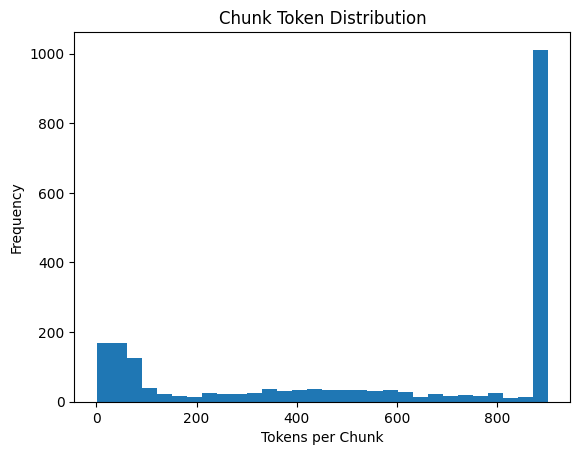

In [10]:
import matplotlib.pyplot as plt

# detect token column automatically
token_col = None
for col in ["tokens", "token_len", "chunk_tokens", "token_count"]:
    if col in df.columns:
        token_col = col
        break

if token_col is not None:
    plt.hist(df[token_col], bins=30)
    plt.title("Chunk Token Distribution")
    plt.xlabel("Tokens per Chunk")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("Token column not found. Available columns:", df.columns)

## Repository Structure Awareness

Outputs generated in Week 1 include:

- raw text documents
- document metadata CSV
- chunk metadata parquet
- ingestion logs
- summary JSON report
- README and requirements files

This structure supports future embedding generation
and vector database integration.

## Week 1 Conclusion

In this phase, the foundational data engineering pipeline for the
HR & Compliance RAG system was successfully implemented.

Multiple datasets were ingested, converted into structured documents,
chunked for retrieval readiness, and validated for quality.

This establishes a scalable groundwork for subsequent stages
involving embeddings, vector search, and grounded LLM response generation.